In [1]:
#test
# 
# Idempotent, Colab-safe: import SIP, installing the course-pinned version if missing.
SIP_PIN = "v0.4.0"
try:
    import sip_systemsinsightpipeline as sip
except ImportError:
    %pip install -q "git+https://github.com/vvvasconcelos/SystemsInsightPipeline.git@v0.4.0"
    import sip_systemsinsightpipeline as sip

import numpy as np, pandas as pd, networkx as nx, matplotlib.pyplot as plt
from sip_systemsinsightpipeline import Extract, SDM

XLSX = "kumu_1a.xlsx"
print("SIP", sip.__version__, "ready")

SIP 0.4.0 ready


In [2]:
# --- decorative ---------------------------------------------------------
TEAL, DARK_TEAL, CORAL, SLATE, MINT, AMBER = (
    "#00A39B", "#006661", "#E8633A", "#5F6B7A", "#9FE1CB", "#E6A700")
KIND_COLOR = {"Stock": TEAL, "Auxiliary": MINT, "Constant": AMBER}


def draw_cld(G, ax=None):
    """Node fill = variable kind, edge colour = link sign."""
    ax = ax or plt.subplots(figsize=(8.5, 6))[1]
    pos = nx.spring_layout(G, pos=nx.kamada_kawai_layout(G), k=0.5, iterations=60, seed=7)
    nx.draw_networkx_nodes(
        G, pos, node_size=3000, edgecolors=DARK_TEAL, ax=ax,
        node_color=[KIND_COLOR[G.nodes[n]["kind"]] for n in G])
    nx.draw_networkx_edges(
        G, pos, node_size=3000, width=2, arrowstyle="-|>", arrowsize=18,
        connectionstyle="arc3,rad=0.16", ax=ax,
        edge_color=[TEAL if d["sign"] == "+" else CORAL for *_, d in G.edges(data=True)])
    nx.draw_networkx_labels(G, pos, {n: n.replace(" ", "\n") for n in G}, font_size=8, ax=ax)
    ax.set_title("teal + / coral -   |   stock=teal, auxiliary=mint, constant=amber",
                 color=DARK_TEAL, fontsize=10)
    ax.axis("off")
    ax.legend(handles=[plt.Line2D([], [], marker="o", ls="", markersize=10, label=k,
                                  markerfacecolor=c, markeredgecolor=DARK_TEAL)
                       for k, c in KIND_COLOR.items()], loc="lower left", frameon=False)
    plt.tight_layout()


def plot_spread(lev, voi, title):
    """One box per lever: the distribution of its effect on the outcome."""
    _, ax = plt.subplots(figsize=(8.5, 4.2))
    bp = ax.boxplot(list(lev.values()), vert=False, tick_labels=list(lev),
                    patch_artist=True, medianprops=dict(color=DARK_TEAL, lw=2))
    for box in bp["boxes"]:
        box.set(facecolor=MINT, alpha=.75)
    ax.axvline(0, color=SLATE, ls=":", lw=1)
    ax.set_xlabel(f"Effect on '{voi}'")
    ax.set_title(title, color=DARK_TEAL)
    plt.tight_layout()


def plot_ranking(r, voi):
    """Median effect per lever, 5-95% interval as the error bar."""
    r = r.sort_values("median")
    _, ax = plt.subplots(figsize=(8.5, 3.8))
    ax.barh(r.index, r["median"], color=TEAL, height=.62,
            xerr=[r["median"] - r["lo"], r["hi"] - r["median"]],
            error_kw=dict(ecolor=SLATE, lw=1.4, capsize=4))
    ax.axvline(0, color=SLATE, ls=":", lw=1)
    ax.set_xlabel(f"Median effect on '{voi}'  (bar = 5-95%)")
    ax.set_title("Which lever matters most?", color=DARK_TEAL)
    plt.tight_layout()

In [ ]:
elem = pd.read_excel(XLSX, sheet_name="Elements")
conn = pd.read_excel(XLSX, sheet_name="Connections")

G = nx.DiGraph()
G.add_nodes_from((r.Label, {"kind": r.Type}) for r in elem.itertuples())
G.add_edges_from((r.From, r.To, {"sign": r.Type}) for r in conn.itertuples())

display(elem, conn[["From", "To", "Type"]])
draw_cld(G)

In [ ]:
s = Extract(XLSX).extract_settings()
voi = s.variable_of_interest[0]

for field in ["variable_of_interest", "intervention_variables", "stocks", "auxiliaries", "constants"]:
    print(f"{field:22s}", getattr(s, field))

Variable of interest: Heat waves
with 4 intervention variables
Removed 2.0 incoming links for constant heat preventative measures advice
Removed 2.0 incoming links for constant Global warming

2 feedback loops of maximum length 5
All loops have at least one stock
No interaction terms specified so will solve linear SDM.


Running Simulations: 100%|██████████| 200/200 [00:01<00:00, 112.18it/s]
/var/folders/fg/6lhvzqx15z96v8k11tv6ljdr0000gn/T/ipykernel_38066/2730082404.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(list(lev.values()), vert=False, tick_labels=list(lev),


(aux, stocks, seed)
def run(aux, stocks, seed):
    """Simulate at one pair of sampling bounds. Returns {lever: effects on the VOI}."""
    s.parameter_value_aux = aux
    s.parameter_value_stocks = stocks
    s.seed = seed
    sdm = SDM(s)
    sdm.run_simulations()
    return sdm.get_intervention_effects()[voi]



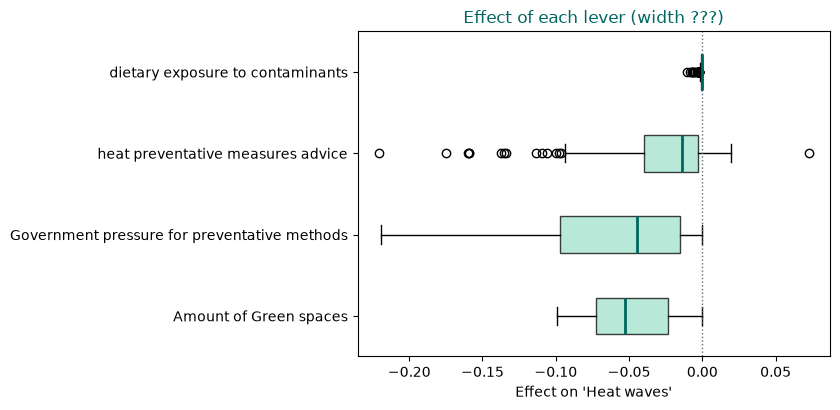

In [ ]:
s = Extract(XLSX).extract_settings()
voi = s.variable_of_interest[0]

s.N, s.t_end, s.time_unit = 200, 25, "years"

def run(aux, stocks, seed):
    """Simulate at one pair of sampling bounds. Returns {lever: effects on the VOI}."""
    s.parameter_value_aux = aux
    s.parameter_value_stocks = stocks
    s.seed = seed
    sdm = SDM(s)
    sdm.run_simulations()
    return sdm.get_intervention_effects()[voi]

def rank(lev):
    """Collapse each lever's distribution to a median and a 5-95% interval."""
    return pd.DataFrame({k: {"median": np.median(v),
                             "lo": np.percentile(v, 5),
                             "hi": np.percentile(v, 95)} for k, v in lev.items()}).T


# TODO 1 - sampling bounds for the unknown link strengths (try 0.1)
base = run(aux=0.1, stocks=0.1, seed=7)

plot_spread(base, voi, "Effect of each lever (width ???)")
